# Regresión logística como clasificador

**Unidad 9 · Machine Learning · Notebook 2 de 6**

Segundo notebook del bloque supervisado. La etiqueta pasa a ser **categórica**, así que
estamos en la rama de **clasificación**.

## Esto no es la unidad 6

La unidad 6 dicta el modelo logit desde la estadística inferencial: se estima, se leen los
coeficientes como *odds ratios*, se testea su significancia y se interpreta el efecto de
cada variable. La pregunta es **¿qué explica que alguien tenga la característica Y?**

Acá usamos el mismo modelo para otra cosa: **asignar categorías a casos nuevos**. La
pregunta es **¿puedo predecir a qué partido se identifica alguien que no encuesté?** Eso
cambia tres cosas concretas:

| | Unidad 6 (inferencial) | Este notebook (predictivo) |
|---|---|---|
| Qué se reporta | coeficientes, errores estándar, p-valores | exactitud, $F_1$, matriz de confusión |
| Sobre qué datos | los que se usaron para estimar | datos que el modelo no vio |
| El éxito es | coeficientes precisos e interpretables | error de predicción bajo |
| El enemigo | sesgo por variable omitida, endogeneidad | sobreajuste |

Las dos lecturas son compatibles y en este notebook las vamos a hacer las dos, porque en
ciencia política casi siempre queremos ambas. Pero conviene no confundirlas: **un modelo
puede predecir bien y tener coeficientes ilegibles**, como vimos en `9.1`, y también lo
inverso.

La regularización L1 y L2 de `9.1` reaparece acá tal cual. No la volvemos a explicar.

## Requisitos

In [1]:
# Requisitos de este notebook.
# Si te falta alguno, instalalo EN TU PROPIO ENTORNO desde una terminal
# (o descomentando la linea de abajo) y reinicia el kernel:
#
#     pip install numpy pandas matplotlib seaborn scikit-learn statsmodels
#
# %pip install numpy pandas matplotlib seaborn scikit-learn statsmodels

import importlib

_requeridos = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn', 'statsmodels']
_faltan = []
for _m in _requeridos:
    try:
        _mod = importlib.import_module(_m)
        print(f"  {_m:16s} {getattr(_mod, '__version__', 'sin version')}")
    except ImportError:
        _faltan.append(_m)
        print(f"  {_m:16s} FALTA")

if _faltan:
    print(f"\nFaltan {len(_faltan)} paquetes: {', '.join(_faltan)}.")
    print("Instalalos en tu entorno antes de seguir.")
else:
    print("\nTodo listo.")

  numpy            1.26.4
  pandas           2.2.2
  matplotlib       3.9.2


  seaborn          0.13.2
  sklearn          1.9.0
  statsmodels      0.14.2

Todo listo.


## Librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, balanced_accuracy_score,
                             classification_report, confusion_matrix, f1_score)
from sklearn.model_selection import (GridSearchCV, RepeatedStratifiedKFold,
                                     StratifiedKFold, cross_val_predict, cross_validate)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

SEED = 42
rng = np.random.default_rng(SEED)
PALETA = ["#0073C2", "#EFC000", "#CD534C", "#868686", "#1E2749"]

## Los datos: una encuesta de identificación política

Una encuesta propia de **134 casos** relevada por formulario web. Además de demografía,
pregunta por posiciones sobre una serie de temas —universidad pública, tarifas, Malvinas,
educación financiera— y por la valoración de ocho países en una escala de $-2$ a $+2$.

La variable a explicar es `ETIQUETA`: con cuál de siete etiquetas políticas se identifica
la persona.

Es una muestra chica y no probabilística. Vamos a tomarla en serio como ejercicio y a ser
explícitos sobre qué se puede y qué no se puede concluir con 134 casos — que es, en sí
mismo, el aprendizaje principal de este notebook.

In [3]:
encuesta = pd.read_excel("../../dataset/encuesta134/134NODUMMY.xlsx")
print(f"casos: {encuesta.shape[0]}   columnas: {encuesta.shape[1]}")

conteo = encuesta["ETIQUETA"].value_counts()
pd.DataFrame({"n": conteo, "%": (conteo / len(encuesta) * 100).round(1)})

casos: 134   columnas: 39


,n,%
ETIQUETA,,
Peronista,60,44.8
De izquierda,19,14.2
No sabe/ No contesta,18,13.4
Apolitico,11,8.2
Liberal,10,7.5
De derecha,7,5.2
Radical,7,5.2
Es una verga la política,1,0.7
Linda,1,0.7


## Depuración: qué se descarta, y por qué

Antes de cualquier modelo. Cada decisión de acá tiene que quedar justificada y escrita,
porque cada una cambia los resultados.

### Etiquetas inválidas

Dos respuestas no son etiquetas políticas: `"Linda"` y `"Es una verga la política"`. Son
respuestas al formulario, no categorías de identificación. Un caso cada una.

In [4]:
INVALIDAS = ["Linda", "Es una verga la política"]
print("Casos con etiqueta inválida:")
print(encuesta.loc[encuesta["ETIQUETA"].isin(INVALIDAS),
                   ["EDAD", "GENERO", "ESTUDIO", "ETIQUETA"]].to_string(index=False))

datos = encuesta[~encuesta["ETIQUETA"].isin(INVALIDAS)].reset_index(drop=True)
print(f"\nn = {len(datos)}, con {datos['ETIQUETA'].nunique()} clases")

Casos con etiqueta inválida:
 EDAD  GENERO  ESTUDIO                 ETIQUETA
   10       1      NaN Es una verga la política
   24       0      1.0                    Linda

n = 132, con 7 clases


### Los extremos de edad

La edad va de 10 a 78 años. Los dos extremos merecen atención separada.

In [5]:
print("Edades extremas en la muestra original:")
print(f"  las 5 más bajas : {sorted(encuesta['EDAD'])[:5]}")
print(f"  las 5 más altas : {sorted(encuesta['EDAD'])[-5:]}")
print()
print(encuesta.loc[(encuesta["EDAD"] < 16) | (encuesta["EDAD"] > 75),
                   ["EDAD", "ESTUDIO", "TRABAJA", "SOCIECON", "ETIQUETA"]].to_string())

Edades extremas en la muestra original:
  las 5 más bajas : [10, 16, 16, 17, 17]
  las 5 más altas : [58, 59, 59, 62, 78]

     EDAD  ESTUDIO  TRABAJA  SOCIECON                  ETIQUETA
43     78      3.0        0         2                 Peronista
124    10      NaN        0         1  Es una verga la política


Dos observaciones:

- **El caso de 10 años** es el mismo que respondió `"Es una verga la política"`, así que ya
  quedó afuera por el filtro anterior. Una edad de 10 años en una encuesta de opinión
  política es implausible y refuerza que ese caso no es utilizable.
- **El caso de 78 años** es legítimo: tiene estudio, nivel socioeconómico y una etiqueta
  válida. **No hay razón para descartarlo.** Es un caso atípico en la distribución de edad
  de esta muestra —que es joven—, pero atípico no es inválido. Descartar observaciones
  porque están lejos del centro, sin un argumento sobre por qué el dato es erróneo,
  introduce sesgo y estrecha artificialmente el rango de la variable.

Nos quedamos con él.

### Variables que no se pueden usar

Tres columnas están rotas o vacías, por errores de diseño del cuestionario.

In [6]:
for col in ["NH_EDAD", "TH_EDAD", "N_BUSCA_HIJOS", "N_HIJOS_HOY"]:
    s = datos[col]
    print(f"{col:15s} nulos = {s.isna().sum():3d}/{len(datos)}   "
          f"rango observado = [{s.min()}, {s.max()}]")

print("\nValores más altos de NH_EDAD ('¿a qué edad te imaginás teniendo tu primer hijo?'):")
print(f"  {sorted(datos['NH_EDAD'].dropna())[-6:]}")

NH_EDAD         nulos =  20/132   rango observado = [1.0, 10000.0]
TH_EDAD         nulos = 112/132   rango observado = [19.0, 37.0]
N_BUSCA_HIJOS   nulos = 130/132   rango observado = [4.0, 4.0]
N_HIJOS_HOY     nulos =   0/132   rango observado = [0, 3]

Valores más altos de NH_EDAD ('¿a qué edad te imaginás teniendo tu primer hijo?'):
  [40.0, 43.0, 45.0, 50.0, 100.0, 10000.0]


- **`NH_EDAD`** llega a **10000**. La pregunta se mostró también a quienes habían dicho no
  querer hijos, y esas personas señalaron la inconsistencia respondiendo valores absurdos.
  Es un error de lógica del formulario. La variable no es recuperable: los valores válidos y
  los de protesta no se distinguen entre sí.
- **`TH_EDAD`** falta en el 86% de los casos (solo aplica a quienes ya tienen hijos).
- **`N_BUSCA_HIJOS`** falta en 130 de 132 casos y su único valor observado es 4.

Las tres se excluyen del set predictor. Notar que el criterio no es "tiene outliers" sino
**sabemos por qué el dato es inválido**: es la misma distinción que aplicamos al caso de 78
años, en la dirección opuesta.

## Faltantes estructurales: por qué imputar la moda sería un error

Varias columnas tienen muchos nulos. La pregunta obligada es **por qué faltan**, porque la
respuesta determina qué hacer.

In [7]:
nulos = datos.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
pd.DataFrame({"nulos": nulos, "%": (nulos / len(datos) * 100).round(1)})

,nulos,%
N_BUSCA_HIJOS,130,98.5
TH_EDAD,112,84.8
DESIGUALDAD,70,53.0
NO_PIENSAN,62,47.0
BUSCA_HIJOS,34,25.8
GRUPO,33,25.0
PROLE,33,25.0
NH_EDAD,20,15.2
ESTUDIO,3,2.3
UP,1,0.8


In [8]:
# ¿DESIGUALDAD y NO_PIENSAN faltan al azar, o son ramas de otra pregunta?
print("EL_PROBLEMA vs. si falta DESIGUALDAD:")
print(pd.crosstab(datos["EL_PROBLEMA"], datos["DESIGUALDAD"].isna(),
                  rownames=["EL_PROBLEMA"], colnames=["falta DESIGUALDAD"]))
print("\nEL_PROBLEMA vs. si falta NO_PIENSAN:")
print(pd.crosstab(datos["EL_PROBLEMA"], datos["NO_PIENSAN"].isna(),
                  rownames=["EL_PROBLEMA"], colnames=["falta NO_PIENSAN"]))

EL_PROBLEMA vs. si falta DESIGUALDAD:
falta DESIGUALDAD  False  True 
EL_PROBLEMA                    
0                      0     70
1                     62      0

EL_PROBLEMA vs. si falta NO_PIENSAN:
falta NO_PIENSAN  False  True 
EL_PROBLEMA                   
0                    70      0
1                     0     62


In [9]:
# ¿Y los 35 nulos de GRUPO y PROLE?
print("¿GRUPO y PROLE faltan en los mismos casos?",
      (datos["GRUPO"].isna() == datos["PROLE"].isna()).all())
print("\nTRABAJA vs. si falta GRUPO:")
print(pd.crosstab(datos["TRABAJA"], datos["GRUPO"].isna(),
                  rownames=["TRABAJA"], colnames=["falta GRUPO"]))

¿GRUPO y PROLE faltan en los mismos casos? True

TRABAJA vs. si falta GRUPO:
falta GRUPO  False  True 
TRABAJA                  
0                0     33
1               99      0


Las tablas son **perfectamente diagonales**, y eso cambia todo:

- `DESIGUALDAD` se preguntó **solo** a quienes respondieron `EL_PROBLEMA = 1`, y
  `NO_PIENSAN` **solo** a los que respondieron `0`. Son las dos ramas de una pregunta con
  bifurcación: los 72 nulos de una son exactamente los 72 casos que contestaron la otra.
- `GRUPO` y `PROLE` faltan en **exactamente** los 35 casos que no trabajan. La pregunta
  nunca se les mostró.

Estos no son datos perdidos: son datos que **no existen**. Nadie omitió una respuesta —la
pregunta no se hizo. En la jerarquía habitual de mecanismos de faltantes (MCAR, MAR, MNAR)
esto es un cuarto caso, a veces llamado *faltante estructural* o *por diseño*.

**Imputar la moda acá es un error conceptual**, no una aproximación imperfecta. Poner "la
respuesta más frecuente" en la celda de alguien a quien nunca se le preguntó inventa una
opinión, y además destruye información: el hecho de que a esa persona no se le preguntara
es un dato: significa que contestó `0` en la pregunta anterior.

La solución correcta es **codificar la estructura explícitamente**.

In [10]:
# Las dos ramas se combinan en UNA variable de cuatro niveles, sin inventar nada
datos["PROBLEMA_RAMA"] = np.where(
    datos["EL_PROBLEMA"] == 1,
    np.where(datos["DESIGUALDAD"] == 1, "concentracion_riqueza_si", "concentracion_riqueza_no"),
    np.where(datos["NO_PIENSAN"] == 1, "no_piensan_si", "no_piensan_no"))

print("PROBLEMA_RAMA (combina EL_PROBLEMA con su pregunta de seguimiento):")
print(datos["PROBLEMA_RAMA"].value_counts().to_string())
print(f"\nnulos: {datos['PROBLEMA_RAMA'].isna().sum()}")

PROBLEMA_RAMA (combina EL_PROBLEMA con su pregunta de seguimiento):
PROBLEMA_RAMA
concentracion_riqueza_no    52
no_piensan_no               38
no_piensan_si               32
concentracion_riqueza_si    10

nulos: 0


In [11]:
# "No aplica" es una categoría legítima, no un faltante
for col in ["GRUPO", "PROLE"]:
    datos[col] = datos[col].fillna("No aplica / no trabaja")

print(datos["GRUPO"].value_counts().to_string())
print()
print(datos["PROLE"].value_counts().to_string())

GRUPO
Empleado/a                59
No aplica / no trabaja    33
Profesional               29
Emprendedor/a             10
Empresario/a               1

PROLE
Los trabajadores /La clase trabajadora    84
No aplica / no trabaja                    33
Otro grupo                                11
No lo sé                                   4


In [12]:
# HIJOS_COMBINADA: tiene hijos, o no los tiene pero quiere tenerlos
datos["HIJOS_COMB"] = np.where(
    datos["HIJOS"] == 1, 1.0,
    np.where((datos["HIJOS"] == 0) & (datos["BUSCA_HIJOS"] == 1), 1.0,
             np.where(datos["BUSCA_HIJOS"].isna(), np.nan, 0.0)))

print(pd.crosstab(datos["HIJOS"], datos["HIJOS_COMB"], dropna=False,
                  rownames=["tiene hijos"], colnames=["HIJOS_COMB"]))
print(f"\nnulos restantes en HIJOS_COMB: {int(datos['HIJOS_COMB'].isna().sum())} "
      "(no tienen hijos y no saben si quieren)")

HIJOS_COMB   0.0  1.0  NaN
tiene hijos               
0             22   58   32
1              0   20    0

nulos restantes en HIJOS_COMB: 32 (no tienen hijos y no saben si quieren)


## Dos patologías que hay que buscar antes de modelar

### Varianza casi nula

Una variable en la que el 98% de los casos responde lo mismo no puede discriminar entre
grupos, por más sustantivamente importante que sea el tema.

In [13]:
BINARIAS = ["UP", "MASCOTHIJO", "GORRA", "EF", "EJERCITO", "TARIFAS", "EMPRESARIOS",
            "MALVINAS", "EF_QUEES", "EL_PROBLEMA", "GENERO", "TRABAJA", "HIJOS"]

reparto = []
for col in BINARIAS:
    p = datos[col].mean(skipna=True)
    reparto.append({"variable": col,
                    "% en 1": round(p * 100, 1),
                    "minoría": round(min(p, 1 - p) * 100, 1)})
pd.DataFrame(reparto).sort_values("minoría").reset_index(drop=True)

,variable,% en 1,minoría
0,UP,97.7,2.3
1,EF,87.9,12.1
2,EJERCITO,84.8,15.2
3,HIJOS,15.2,15.2
4,EF_QUEES,17.4,17.4
5,GORRA,22.0,22.0
6,TRABAJA,75.0,25.0
7,MASCOTHIJO,33.3,33.3
8,TARIFAS,34.8,34.8
9,EMPRESARIOS,35.6,35.6


`UP` —*"la universidad pública en Argentina debe ser gratuita"*— tiene una minoría del
**2.3%**: solo 3 de 132 personas están en desacuerdo. Hay consenso casi total.

### Separación perfecta

Esa variable además produce un problema técnico específico de la regresión logística.

In [14]:
peronista = (datos["ETIQUETA"] == "Peronista").astype(int)
print("UP vs. identificación peronista:")
print(pd.crosstab(datos["UP"], peronista, rownames=["UP"],
                  colnames=["es peronista"], margins=True))

UP vs. identificación peronista:
es peronista   0   1  All
UP                       
0.0            3   0    3
1.0           68  60  128
All           71  60  131


In [15]:
# Qué pasa si se estima un logit con esa variable adentro
X_sep = sm.add_constant(datos[["UP", "TARIFAS", "GORRA"]].fillna(0).astype(float))
modelo_sep = sm.Logit(peronista, X_sep).fit(disp=False)
pd.DataFrame({"coeficiente": modelo_sep.params,
              "odds_ratio": np.exp(modelo_sep.params),
              "error_est": modelo_sep.bse,
              "p_valor": modelo_sep.pvalues}).round(4)

C:\Users\mmill\anaconda3\envs\PYR\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,coeficiente,odds_ratio,error_est,p_valor
const,-21.3025,0.000000e+00,60525.2319,0.9997
UP,21.8137,2.975473e+09,60525.2319,0.9997
TARIFAS,-2.1054,1.218000e-01,0.4766,0.0000
GORRA,-0.1325,8.759000e-01,0.4607,0.7736


El coeficiente de `UP` es enorme, su *odds ratio* es de orden $10^{15}$, y el error estándar
y el p-valor son `NaN`. No es un bug: es **separación cuasi-perfecta**.

La celda `UP = 0, peronista = 1` está **vacía**: ninguna de las 3 personas que se oponen a
la universidad pública gratuita es peronista. Entonces el modelo puede llevar la
probabilidad predicha de esas 3 personas exactamente a cero, y para hacerlo necesita un
coeficiente infinitamente grande. El estimador de máxima verosimilitud **no existe**: la
verosimilitud crece de forma monótona a medida que el coeficiente crece, sin alcanzar nunca
un máximo. El algoritmo se detiene por límite de iteraciones en un número grande y
arbitrario.

Cómo se reconoce en la práctica: coeficientes de magnitud absurda, errores estándar enormes
o `NaN`, y advertencias de convergencia. Cómo se resuelve:

1. **Sacar la variable**, si además tiene varianza casi nula — nuestro caso.
2. **Penalizarla**: Ridge o Lasso acotan el coeficiente y devuelven una solución finita. La
   regularización de `9.1` resuelve esto además de la colinealidad.
3. **Logística de Firth**, una corrección de sesgo diseñada para este problema, muy usada en
   ciencia política para eventos raros.

Sacamos `UP`: con 3 casos en la minoría no puede sostener ninguna inferencia.

In [16]:
BINARIAS = [c for c in BINARIAS if c != "UP"]

ORDINALES = ["EEUU", "PALESTINA", "ISRAEL", "UCRANIA", "RUSIA", "BOLIVIA", "CHINA",
             "INGLATERRA", "EDAD", "ESTUDIO", "SOCIECON"]
CATEGORICAS = ["SS", "PROGRAMA", "NOTICIAS", "GRUPO", "PROLE", "NO_HIJOS_PQ",
               "PROBLEMA_RAMA"]
NUMERICAS = BINARIAS + ORDINALES + ["HIJOS_COMB"]

# MILEI (satisfacción con el gobierno) se deja afuera a propósito: volvemos sobre eso.
X = datos[NUMERICAS + CATEGORICAS]
y = datos["ETIQUETA"]

print(f"predictores numéricos  : {len(NUMERICAS)}")
print(f"predictores categóricos: {len(CATEGORICAS)}")
print(f"casos                  : {len(X)}")

predictores numéricos  : 24
predictores categóricos: 7
casos                  : 132


## Teoría: de la probabilidad al logit

El problema de usar una regresión lineal para una etiqueta binaria es inmediato: $y$ solo
puede valer 0 o 1, pero una recta no está acotada y predice valores como $-0.3$ o $1.4$, que
no son probabilidades.

La solución es modelar una **transformación** de la probabilidad que sí pueda tomar
cualquier valor real. Se llega en dos pasos.

**Paso 1: de la probabilidad a los odds.** Los *odds* son la razón entre la probabilidad de
que ocurra y la de que no ocurra:

$$ \text{odds} = \frac{p}{1-p} $$

Si $p = 0.5$ los odds son 1; si $p = 0.8$ son 4 ("cuatro a uno"). El rango pasa de
$[0, 1]$ a $[0, \infty)$.

**Paso 2: de los odds al logaritmo de los odds.** Tomando logaritmo el rango se abre a toda
la recta real:

$$ \text{logit}(p) = \log\!\left(\frac{p}{1-p}\right) \in (-\infty, +\infty) $$

Y sobre **eso** se plantea el modelo lineal:

$$ \log\!\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \dots + \beta_k x_k $$

Despejando $p$ se obtiene la **función logística**, que es la que le da nombre al modelo:

$$ p = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_k x_k)}} = \sigma(x'\beta) $$

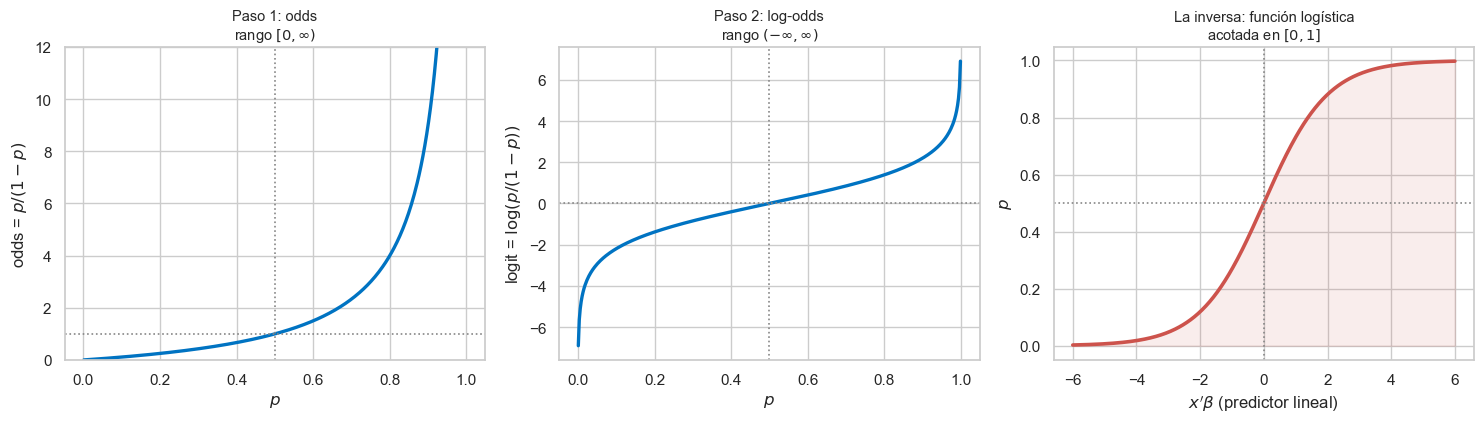

In [17]:
z = np.linspace(-6, 6, 400)
sigma = 1 / (1 + np.exp(-z))
p_grid = np.linspace(0.001, 0.999, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

axes[0].plot(p_grid, p_grid / (1 - p_grid), lw=2.4, color=PALETA[0])
axes[0].axhline(1, color=PALETA[3], ls=":", lw=1.2)
axes[0].axvline(0.5, color=PALETA[3], ls=":", lw=1.2)
axes[0].set_ylim(0, 12)
axes[0].set_xlabel("$p$"); axes[0].set_ylabel("odds = $p/(1-p)$")
axes[0].set_title("Paso 1: odds\nrango $[0, \\infty)$", fontsize=10.5)

axes[1].plot(p_grid, np.log(p_grid / (1 - p_grid)), lw=2.4, color=PALETA[0])
axes[1].axhline(0, color=PALETA[3], ls=":", lw=1.2)
axes[1].axvline(0.5, color=PALETA[3], ls=":", lw=1.2)
axes[1].set_xlabel("$p$"); axes[1].set_ylabel("logit = $\\log(p/(1-p))$")
axes[1].set_title("Paso 2: log-odds\nrango $(-\\infty, \\infty)$", fontsize=10.5)

axes[2].plot(z, sigma, lw=2.6, color=PALETA[2])
axes[2].axhline(0.5, color=PALETA[3], ls=":", lw=1.2)
axes[2].axvline(0, color=PALETA[3], ls=":", lw=1.2)
axes[2].fill_between(z, 0, sigma, alpha=0.10, color=PALETA[2])
axes[2].set_xlabel("$x'\\beta$ (predictor lineal)"); axes[2].set_ylabel("$p$")
axes[2].set_title("La inversa: función logística\nacotada en $[0, 1]$", fontsize=10.5)

plt.tight_layout()
plt.show()

### Cómo se lee un coeficiente

Como el modelo es lineal **en los log-odds**, un coeficiente $\beta_j$ dice cuánto cambia el
logaritmo de los odds ante un aumento unitario en $x_j$. Eso no es interpretable
directamente, así que se exponencia:

$$ e^{\beta_j} = \text{odds ratio} $$

El *odds ratio* es **multiplicativo** sobre los odds:

- $e^{\beta_j} = 1$ → la variable no cambia los odds.
- $e^{\beta_j} = 2$ → un aumento unitario en $x_j$ **duplica** los odds.
- $e^{\beta_j} = 0.5$ → los reduce a la mitad.

La trampa clásica: un *odds ratio* **no** es un cociente de probabilidades. Duplicar los
odds de un evento que tenía $p = 0.5$ lo lleva a $p = 0.67$, no a 1.

### Cómo se estima

No hay solución cerrada como $(X'X)^{-1}X'y$. Se maximiza la **log-verosimilitud**

$$ \ell(\beta) = \sum_{i=1}^{n} \Big[ y_i \log p_i + (1-y_i)\log(1-p_i) \Big] $$

numéricamente, con métodos iterativos (Newton-Raphson, L-BFGS, SAGA). Es la misma cantidad
que en machine learning se llama *log loss* o *entropía cruzada*, con signo cambiado:
maximizar la verosimilitud y minimizar la log loss son el mismo problema.

### La frontera de decisión y el umbral

El modelo devuelve una **probabilidad**, no una clase. Para convertirla en clase hace falta
un **umbral**, que por defecto es 0.5.

Como $p = 0.5$ equivale a $x'\beta = 0$, la frontera de decisión de la logística es un
**hiperplano**: una recta con dos predictores, un plano con tres. Esa es su principal
limitación y el motivo por el que existen los árboles de `9.3`: si la separación real entre
grupos no es aproximadamente lineal, la logística no la puede representar.

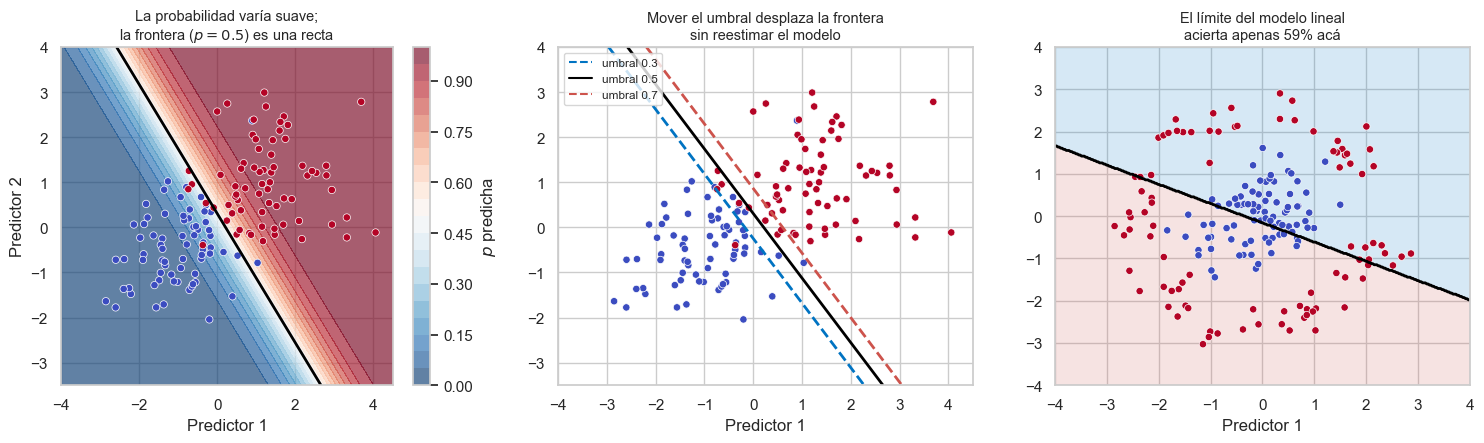

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

# datos de ejemplo: dos grupos linealmente separables
Xe = np.vstack([rng.normal([-1, -0.4], 0.95, (70, 2)),
                rng.normal([1.3, 1.0], 0.95, (70, 2))])
ye = np.r_[np.zeros(70), np.ones(70)]
logit_ej = LogisticRegression().fit(Xe, ye)

g1, g2 = np.meshgrid(np.linspace(-4, 4.5, 300), np.linspace(-3.5, 4, 300))
proba = logit_ej.predict_proba(np.c_[g1.ravel(), g2.ravel()])[:, 1].reshape(g1.shape)

# panel 1: superficie de probabilidad
cs = axes[0].contourf(g1, g2, proba, levels=20, cmap="RdBu_r", alpha=0.65)
axes[0].contour(g1, g2, proba, levels=[0.5], colors="black", linewidths=2)
plt.colorbar(cs, ax=axes[0], label="$p$ predicha")
axes[0].scatter(Xe[:, 0], Xe[:, 1], c=ye, cmap="coolwarm", s=28,
                edgecolor="white", lw=0.5)
axes[0].set_title("La probabilidad varía suave;\nla frontera ($p=0.5$) es una recta",
                  fontsize=10.5)

# panel 2: tres umbrales
for umbral, color, ls in [(0.3, PALETA[0], "--"), (0.5, "black", "-"), (0.7, PALETA[2], "--")]:
    axes[1].contour(g1, g2, proba, levels=[umbral], colors=[color], linewidths=2,
                    linestyles=[ls])
axes[1].scatter(Xe[:, 0], Xe[:, 1], c=ye, cmap="coolwarm", s=28,
                edgecolor="white", lw=0.5)
from matplotlib.lines import Line2D
axes[1].legend(handles=[Line2D([], [], color=PALETA[0], ls="--", label="umbral 0.3"),
                        Line2D([], [], color="black", label="umbral 0.5"),
                        Line2D([], [], color=PALETA[2], ls="--", label="umbral 0.7")],
               fontsize=8.5, loc="upper left")
axes[1].set_title("Mover el umbral desplaza la frontera\nsin reestimar el modelo",
                  fontsize=10.5)

# panel 3: cuando la separación no es lineal
ang = rng.uniform(0, 2 * np.pi, 90)
Xn = np.vstack([rng.normal(0, 0.62, (90, 2)),
                np.c_[2.4 * np.cos(ang), 2.4 * np.sin(ang)] + rng.normal(0, 0.32, (90, 2))])
yn = np.r_[np.zeros(90), np.ones(90)]
logit_no = LogisticRegression().fit(Xn, yn)
gg1, gg2 = np.meshgrid(np.linspace(-4, 4, 300), np.linspace(-4, 4, 300))
Zn = logit_no.predict(np.c_[gg1.ravel(), gg2.ravel()]).reshape(gg1.shape)
axes[2].contourf(gg1, gg2, Zn, alpha=0.16, colors=[PALETA[0], PALETA[2]],
                 levels=[-0.5, 0.5, 1.5])
axes[2].contour(gg1, gg2, Zn, levels=[0.5], colors="black", linewidths=2)
axes[2].scatter(Xn[:, 0], Xn[:, 1], c=yn, cmap="coolwarm", s=28,
                edgecolor="white", lw=0.5)
axes[2].set_title(f"El límite del modelo lineal\nacierta apenas "
                  f"{logit_no.score(Xn, yn):.0%} acá", fontsize=10.5)

for ax in axes:
    ax.set_xlabel("Predictor 1")
axes[0].set_ylabel("Predictor 2")
plt.tight_layout()
plt.show()

### Más de dos clases

Nuestra etiqueta tiene siete categorías. Dos formas de extender el modelo:

**Multinomial (softmax).** Se estima un vector de coeficientes por clase y las
probabilidades salen de normalizar:

$$ P(y = k \mid x) = \frac{e^{x'\beta_k}}{\sum_{j=1}^{K} e^{x'\beta_j}} $$

Las $K$ probabilidades suman 1 por construcción. Es un único modelo conjunto, y es lo que
scikit-learn hace por defecto.

**Uno contra el resto (*one-vs-rest*).** Se estiman $K$ modelos binarios independientes
—"peronista sí/no", "radical sí/no"— y se toma el de mayor probabilidad. Más simple de
interpretar clase por clase, pero las probabilidades no suman 1.

El costo del multinomial: con $K$ clases y $p$ predictores hay $(K-1) \times (p+1)$
parámetros a estimar. Con 7 clases y 57 columnas eso son **348 parámetros para 132
observaciones**. Volveremos sobre ese número, porque explica todo lo que sigue.

## El pipeline

Siguiendo la regla de `9.0`: **todo el preprocesamiento va adentro**, para que se ajuste
solo con los datos de entrenamiento de cada pliegue.

Dos detalles del preprocesamiento categórico que importan con muestras chicas:

- `min_frequency=6` agrupa en una categoría `infrequent` a los niveles con menos de 6 casos.
  Sin eso, una categoría con 2 casos genera una columna dummy que es casi toda ceros: no
  aporta señal y sí varianza. `NO_HIJOS_PQ` tiene siete niveles, varios con pocos casos.
- `handle_unknown="infrequent_if_exist"` evita que el pipeline se rompa cuando un nivel
  presente en el pliegue de validación no apareció en el de entrenamiento — algo que con
  $n = 132$ pasa todo el tiempo.

In [19]:
preprocesador = ColumnTransformer([
    ("num", Pipeline([("imputar", SimpleImputer(strategy="median")),
                      ("escalar", StandardScaler())]), NUMERICAS),
    ("cat", Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),
                      ("dummies", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                                min_frequency=6,
                                                sparse_output=False))]), CATEGORICAS),
])

X_transformada = preprocesador.fit_transform(X)
print(f"matriz de diseño: {X_transformada.shape[0]} filas × {X_transformada.shape[1]} columnas")
print(f"p / n = {X_transformada.shape[1] / X_transformada.shape[0]:.2f}")
print(f"\nparámetros a estimar con 7 clases: "
      f"{6 * (X_transformada.shape[1] + 1)} para {len(X)} observaciones")

matriz de diseño: 132 filas × 56 columnas
p / n = 0.42

parámetros a estimar con 7 clases: 342 para 132 observaciones


Dos cosas para leer el código que viene. El tipo de penalización se elige con `l1_ratio`:
`0.0` es Ridge, `1.0` es Lasso, y los intermedios Elastic Net — la misma parametrización de
`9.1`. Y **`C` es el inverso de la fuerza de penalización**, $C = 1/\lambda$: con $C$ chico se
penaliza mucho. Va al revés de lo intuitivo, así que conviene tenerlo presente al leer las
tablas.

In [20]:
def armar_logit(C=1.0, l1_ratio=0.0):
    return Pipeline([
        ("pre", preprocesador),
        ("clf", LogisticRegression(C=C, l1_ratio=l1_ratio, solver="saga",
                                   max_iter=20000, random_state=SEED)),
    ])

CV = RepeatedStratifiedKFold(n_splits=5, n_repeats=6, random_state=SEED)
METRICAS = ["accuracy", "f1_macro", "balanced_accuracy"]

def evaluar(estimador, X, y, nombre):
    r = cross_validate(estimador, X, y, cv=CV, scoring=METRICAS, n_jobs=-1)
    return {"modelo": nombre,
            "exactitud": r["test_accuracy"].mean(),
            "exac_sd": r["test_accuracy"].std(),
            "f1_macro": r["test_f1_macro"].mean(),
            "f1_sd": r["test_f1_macro"].std(),
            "exac_balanceada": r["test_balanced_accuracy"].mean()}

## El baseline, primero

Antes de cualquier modelo.

In [21]:
filas = [evaluar(DummyClassifier(strategy="most_frequent", random_state=SEED), X, y,
                 "BASELINE (clase mayoritaria)"),
         evaluar(DummyClassifier(strategy="stratified", random_state=SEED), X, y,
                 "BASELINE (al azar según proporciones)")]
pd.DataFrame(filas).round(3)

,modelo,exactitud,exac_sd,f1_macro,f1_sd,exac_balanceada
0,BASELINE (clase mayoritaria),0.455,0.008,0.089,0.001,0.143
1,BASELINE (al azar según proporciones),0.262,0.062,0.109,0.042,0.115


La vara es **45.5% de exactitud**, con un $F_1$ macro de apenas **0.089**. La brecha enorme
entre las dos métricas es la firma del desbalanceo: acertar siempre "Peronista" da una
exactitud casi aceptable y un $F_1$ macro pésimo, porque seis de las siete clases tienen
$F_1 = 0$.

## Ajuste con las siete clases

Elegimos $C$ y `l1_ratio` por validación cruzada, sobre una grilla. Notar que la búsqueda
está anidada en la misma CV que reporta el resultado, lo cual es levemente optimista; con
$n = 132$ una CV anidada de verdad tendría pliegues de 26 casos y el ruido dominaría todo.
Lo señalamos como limitación en lugar de esconderlo.

In [22]:
rejilla = {"clf__C": np.logspace(-2.5, 1.5, 12),
           "clf__l1_ratio": [0.0, 0.5, 1.0]}

busqueda = GridSearchCV(armar_logit(), rejilla, cv=CV, scoring="f1_macro", n_jobs=-1)
busqueda.fit(X, y)

print(f"mejor C        = {busqueda.best_params_['clf__C']:.4f}")
print(f"mejor l1_ratio = {busqueda.best_params_['clf__l1_ratio']}  "
      f"({'Ridge' if busqueda.best_params_['clf__l1_ratio']==0 else 'Lasso' if busqueda.best_params_['clf__l1_ratio']==1 else 'Elastic Net'})")
print(f"F1 macro       = {busqueda.best_score_:.3f}")

mejor C        = 0.4806
mejor l1_ratio = 1.0  (Lasso)
F1 macro       = 0.236


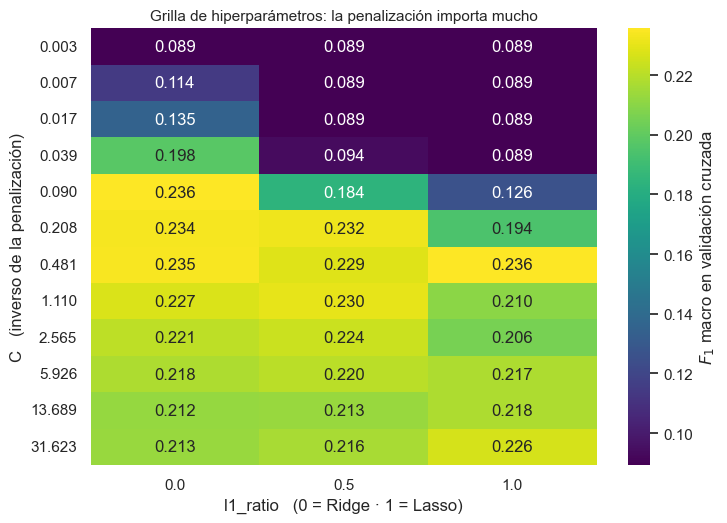

In [23]:
# La superficie de la búsqueda: cómo depende el resultado de la penalización
res = pd.DataFrame(busqueda.cv_results_)
tabla = res.pivot_table(index="param_clf__C", columns="param_clf__l1_ratio",
                        values="mean_test_score")

fig, ax = plt.subplots(figsize=(7.5, 5.4))
sns.heatmap(tabla, annot=True, fmt=".3f", cmap="viridis",
            cbar_kws={"label": "$F_1$ macro en validación cruzada"}, ax=ax)
ax.set_xlabel("l1_ratio   (0 = Ridge · 1 = Lasso)")
ax.set_ylabel("C   (inverso de la penalización)")
ax.set_yticklabels([f"{float(t.get_text()):.3f}" for t in ax.get_yticklabels()], rotation=0)
ax.set_title("Grilla de hiperparámetros: la penalización importa mucho", fontsize=11)
plt.tight_layout()
plt.show()

In [24]:
mejor7 = busqueda.best_estimator_
filas.append(evaluar(mejor7, X, y, "Logit regularizado (7 clases)"))
pd.DataFrame(filas).round(3)

,modelo,exactitud,exac_sd,f1_macro,f1_sd,exac_balanceada
0,BASELINE (clase mayoritaria),0.455,0.008,0.089,0.001,0.143
1,BASELINE (al azar según proporciones),0.262,0.062,0.109,0.042,0.115
2,Logit regularizado (7 clases),0.494,0.074,0.236,0.078,0.250


El modelo **le gana al baseline**, y conviene decir con precisión cuánto:

- La exactitud sube de 0.455 a **0.494**: unos 4 puntos.
- El $F_1$ macro pasa de 0.089 a **0.236**, o sea se **multiplica por 2.7**.
- La exactitud balanceada sube de 0.143 (que es $1/7$) a **0.250**.

O sea: **sí hay señal** en las opiniones y la demografía para predecir identificación
política, y se ve mucho mejor en el $F_1$ macro que en la exactitud — justamente porque el
$F_1$ macro premia acertar en las clases chicas.

Pero mirá el desvío: **0.074 sobre una ganancia de 4 puntos de exactitud**. La mejora es
menor que la variabilidad entre pliegues, así que en exactitud el modelo y el baseline
**empatan** según la regla que fijamos en `9.0`. El $F_1$ macro sí muestra una diferencia
real (0.236 contra 0.089, con desvío 0.078). La conclusión honesta es que el modelo aprende
algo que la exactitud no sabe medir.

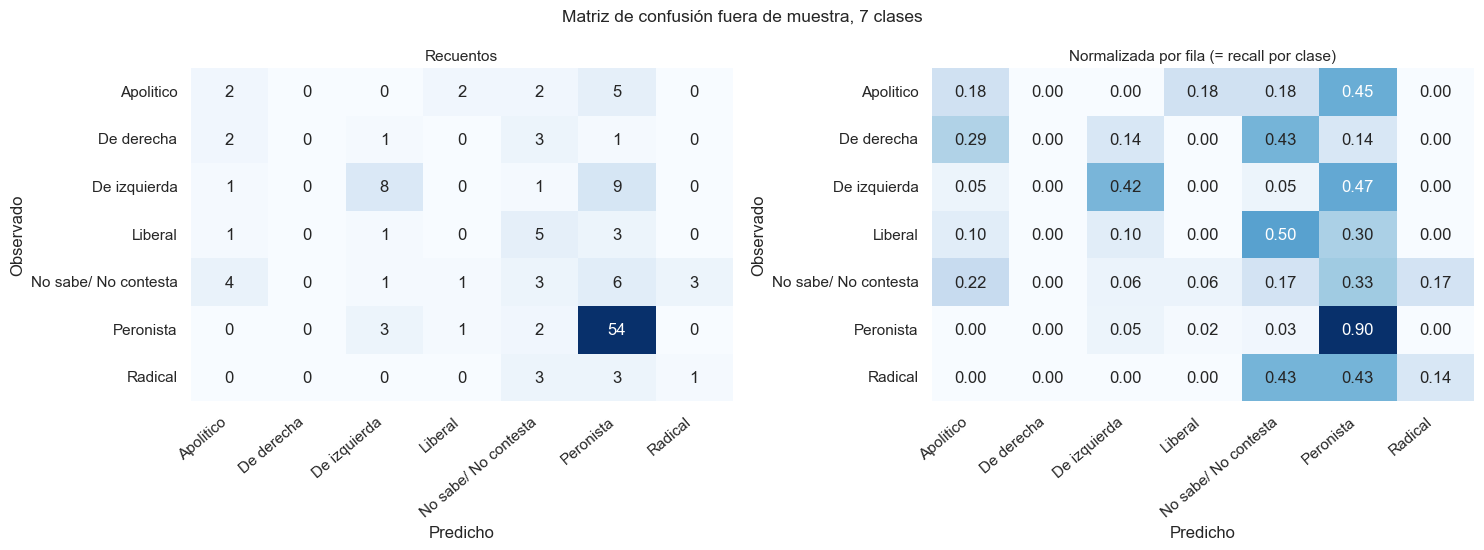

In [25]:
# Matriz de confusión fuera de muestra: una partición sin repeticiones, para que
# cada caso reciba exactamente una predicción.
CV_PRED = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_pred = cross_val_predict(mejor7, X, y, cv=CV_PRED, n_jobs=-1)
etiquetas = sorted(y.unique())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
for ax, normaliza, titulo in [
        (axes[0], None, "Recuentos"),
        (axes[1], "true", "Normalizada por fila (= recall por clase)")]:
    cm = confusion_matrix(y, y_pred, labels=etiquetas, normalize=normaliza)
    sns.heatmap(cm, annot=True, fmt="d" if normaliza is None else ".2f",
                cmap="Blues", xticklabels=etiquetas, yticklabels=etiquetas,
                cbar=False, ax=ax)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Observado")
    ax.set_title(titulo, fontsize=11)
    ax.tick_params(axis="x", rotation=40)
    for t in ax.get_xticklabels():
        t.set_ha("right")
fig.suptitle("Matriz de confusión fuera de muestra, 7 clases", fontsize=12.5)
plt.tight_layout()
plt.show()

In [26]:
print(classification_report(y, y_pred, zero_division=0))

                      precision    recall  f1-score   support

           Apolitico       0.20      0.18      0.19        11
          De derecha       0.00      0.00      0.00         7
        De izquierda       0.57      0.42      0.48        19
             Liberal       0.00      0.00      0.00        10
No sabe/ No contesta       0.16      0.17      0.16        18
           Peronista       0.67      0.90      0.77        60
             Radical       0.25      0.14      0.18         7

            accuracy                           0.52       132
           macro avg       0.26      0.26      0.26       132
        weighted avg       0.44      0.52      0.47       132



Acá está el problema, y no lo muestra la exactitud sino el reporte por clase: la columna
`support` dice cuántos casos reales hay de cada etiqueta, y para **De derecha**, **Radical**
y **Liberal** son 7, 7 y 10. Con esos números, en cada pliegue de validación hay **uno o dos
casos** de esas clases. El modelo casi nunca las predice, y cuando lo hace es azar.

La matriz de confusión normalizada lo hace visible: la columna de "Peronista" está poblada
—el modelo tira para ahí— y las filas de las clases chicas están casi vacías en su diagonal.

Esto no se arregla con un modelo mejor. Es una limitación de los datos.

In [27]:
# Cuántos casos de cada clase caen en un pliegue de validación
tam = y.value_counts().sort_values()
pd.DataFrame({
    "casos en la muestra": tam,
    "casos por pliegue (1/5)": (tam / 5).round(1),
}).assign(**{"¿estimable?": lambda t: np.where(t["casos por pliegue (1/5)"] >= 3,
                                               "sí", "no")})

,casos en la muestra,casos por pliegue (1/5),¿estimable?
ETIQUETA,,,
De derecha,7,1.4,no
Radical,7,1.4,no
Liberal,10,2.0,no
Apolitico,11,2.2,no
No sabe/ No contesta,18,3.6,sí
De izquierda,19,3.8,sí
Peronista,60,12.0,sí


## Re-especificar: menos clases

Si el problema es que hay siete clases y 132 casos, una salida es **agrupar categorías**.

Pero hay que ser honestos sobre lo que eso significa: **agrupar clases no es mejorar el
modelo, es cambiar la pregunta de investigación**. Un modelo que distingue tres bloques
ideológicos responde algo distinto de uno que distingue siete etiquetas partidarias, y la
mejora en las métricas no es evidencia de nada excepto de que el problema nuevo es más
fácil.

Se justifica cuando el agrupamiento tiene sentido sustantivo *antes* de ver los resultados.
Probamos dos agrupamientos y decimos de antemano por qué:

- **Tres bloques ideológicos**: peronismo e izquierda por un lado, derecha y liberales por
  otro, y sin adscripción clara en el tercero. El análisis descriptivo de estos datos y la
  literatura sobre el sistema de partidos argentino sostienen que peronismo e izquierda
  comparten posiciones en varios de los temas relevados.
- **Peronismo contra todo el resto**: la división más gruesa posible, y la que más
  claramente estructura la competencia política argentina.

In [28]:
MAPA_3 = {"Peronista": "Peronismo/Izquierda", "De izquierda": "Peronismo/Izquierda",
          "Liberal": "Derecha/Liberal", "De derecha": "Derecha/Liberal",
          "Radical": "Sin adscripción clara", "Apolitico": "Sin adscripción clara",
          "No sabe/ No contesta": "Sin adscripción clara"}

y3 = y.map(MAPA_3)
y2 = pd.Series(np.where(y == "Peronista", "Peronista", "No peronista"), index=y.index)

for nombre, yy in [("7 clases", y), ("3 clases", y3), ("2 clases", y2)]:
    vc = yy.value_counts()
    print(f"{nombre}: baseline = {vc.iloc[0]/len(yy):.3f}   ->  {dict(vc)}")

7 clases: baseline = 0.455   ->  {'Peronista': 60, 'De izquierda': 19, 'No sabe/ No contesta': 18, 'Apolitico': 11, 'Liberal': 10, 'De derecha': 7, 'Radical': 7}
3 clases: baseline = 0.598   ->  {'Peronismo/Izquierda': 79, 'Sin adscripción clara': 36, 'Derecha/Liberal': 17}
2 clases: baseline = 0.545   ->  {'No peronista': 72, 'Peronista': 60}


In [29]:
comparacion = []
for nombre, yy in [("7 clases", y), ("3 clases", y3), ("2 clases", y2)]:
    comparacion.append(evaluar(DummyClassifier(strategy="most_frequent"), X, yy,
                               f"BASELINE · {nombre}"))
    gs = GridSearchCV(armar_logit(), rejilla, cv=CV, scoring="f1_macro", n_jobs=-1)
    gs.fit(X, yy)
    fila = evaluar(gs.best_estimator_, X, yy, f"Logit regularizado · {nombre}")
    fila["C"] = round(gs.best_params_["clf__C"], 4)
    fila["l1_ratio"] = gs.best_params_["clf__l1_ratio"]
    comparacion.append(fila)

tabla_comp = pd.DataFrame(comparacion)
tabla_comp.round(3)

,modelo,exactitud,exac_sd,f1_macro,f1_sd,exac_balanceada,C,l1_ratio
0,BASELINE · 7 clases,0.455,0.008,0.089,0.001,0.143,NaN,NaN
1,Logit regularizado · 7 clases,0.494,0.074,0.236,0.078,0.250,0.481,1.0
2,BASELINE · 3 clases,0.599,0.015,0.250,0.004,0.333,NaN,NaN
3,Logit regularizado · 3 clases,0.698,0.062,0.487,0.072,0.499,0.090,0.0
4,BASELINE · 2 clases,0.545,0.008,0.353,0.003,0.500,NaN,NaN
5,Logit regularizado · 2 clases,0.791,0.069,0.787,0.070,0.789,0.208,0.5


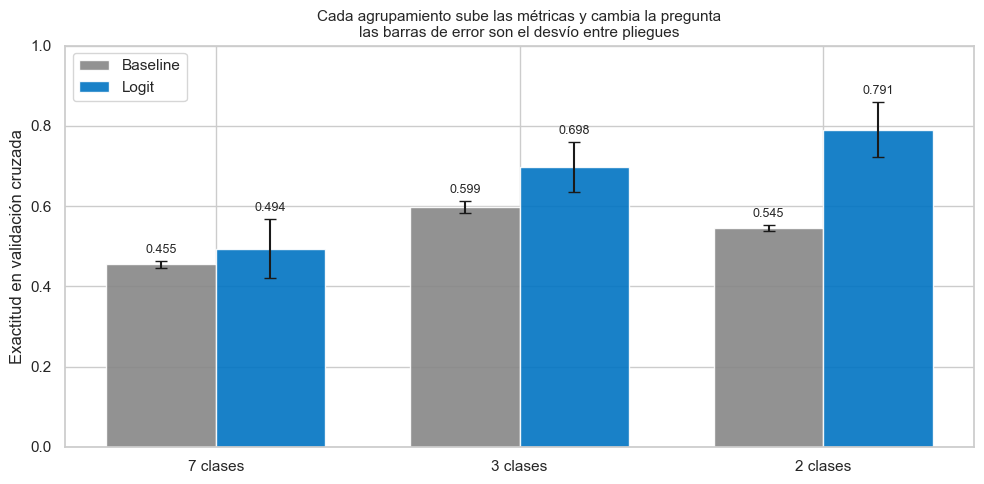

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
t = tabla_comp.copy()
t["tipo"] = np.where(t["modelo"].str.startswith("BASELINE"), "Baseline", "Logit")
t["esquema"] = t["modelo"].str.extract(r"(\d+ clases)")

ancho = 0.36
x_pos = np.arange(3)
for i, (tipo, color) in enumerate([("Baseline", PALETA[3]), ("Logit", PALETA[0])]):
    sub = t[t["tipo"] == tipo].set_index("esquema").loc[["7 clases", "3 clases", "2 clases"]]
    ax.bar(x_pos + (i - 0.5) * ancho, sub["exactitud"], ancho,
           yerr=sub["exac_sd"], capsize=4, label=tipo, color=color, alpha=0.9)
    for j, (v, s) in enumerate(zip(sub["exactitud"], sub["exac_sd"])):
        ax.text(j + (i - 0.5) * ancho, v + s + 0.02, f"{v:.3f}",
                ha="center", fontsize=9)
ax.set_xticks(x_pos); ax.set_xticklabels(["7 clases", "3 clases", "2 clases"])
ax.set_ylabel("Exactitud en validación cruzada")
ax.set_ylim(0, 1.0)
ax.set_title("Cada agrupamiento sube las métricas y cambia la pregunta\n"
             "las barras de error son el desvío entre pliegues", fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

Los tres esquemas le ganan a su propio baseline, y la ventaja crece al agrupar:

| Esquema | Baseline | Logit | Ganancia | Desvío | ¿Supera al ruido? |
|---|---|---|---|---|---|
| 7 clases | 0.455 | 0.494 | +4 puntos | 0.074 | no |
| 3 clases | 0.599 | 0.698 | +10 puntos | 0.062 | sí, apenas |
| 2 clases | 0.545 | 0.791 | +25 puntos | 0.069 | sí, con holgura |

La lectura correcta **no** es "el modelo de 2 clases es el mejor". Es:

- Con siete etiquetas partidarias, la ganancia en exactitud queda por debajo del desvío
  entre pliegues: esta muestra permite detectar señal pero no construir un clasificador
  utilizable.
- Con la división peronismo/no peronismo, el modelo pasa a ser genuinamente informativo:
  acierta 4 de cada 5 casos contra un baseline de poco más de la mitad, la ganancia es más
  de tres veces el desvío, y su $F_1$ macro de **0.787** dice que le va bien en las dos
  clases, no solo en la grande.
- El esquema de 3 clases queda en el medio: gana 10 puntos con un desvío de 0.062, o sea
  algo más de un desvío y medio. Es defendible pero no contundente.

Y una consecuencia sustantiva: que la división binaria funcione tan mejor sugiere que **el
eje que estas variables capturan es peronismo contra no peronismo**, no una escala
ideológica de siete posiciones.

## Interpretación: odds ratios con intervalos de confianza

Hasta acá medimos performance. Ahora la otra lectura: **qué dicen los coeficientes**.

Y acá hay que cambiar de herramienta. Los coeficientes de un modelo regularizado de
scikit-learn **no sirven para inferencia**: están sesgados a propósito (es lo que hace la
penalización) y la librería no calcula errores estándar. Para odds ratios con intervalos de
confianza y p-valores hay que estimar por máxima verosimilitud sin penalización, y eso lo da
`statsmodels`.

Usamos el modelo binario —peronista contra el resto— con un subconjunto de predictores
elegido por criterio sustantivo. Con 132 casos, meter 57 columnas en un modelo no
regularizado devolvería errores estándar inservibles.

In [31]:
INTERPRETABLES = ["GORRA", "EMPRESARIOS", "TARIFAS", "MALVINAS", "EJERCITO", "EF",
                  "EF_QUEES", "MASCOTHIJO", "EEUU", "PALESTINA", "ISRAEL", "BOLIVIA",
                  "CHINA", "GENERO", "EDAD", "ESTUDIO", "SOCIECON"]

X_sm = datos[INTERPRETABLES].copy()
for c in X_sm.columns:
    X_sm[c] = X_sm[c].fillna(X_sm[c].median())
X_sm = sm.add_constant(X_sm.astype(float))
y_sm = (datos["ETIQUETA"] == "Peronista").astype(int)

logit_sm = sm.Logit(y_sm, X_sm).fit(disp=False)

print(f"n = {int(logit_sm.nobs)}   pseudo-R² (McFadden) = {logit_sm.prsquared:.3f}")
print(f"log-verosimilitud = {logit_sm.llf:.1f}   (modelo nulo: {logit_sm.llnull:.1f})")
print(f"p-valor del test conjunto (LR) = {logit_sm.llr_pvalue:.5f}")

n = 132   pseudo-R² (McFadden) = 0.376
log-verosimilitud = -56.8   (modelo nulo: -90.9)
p-valor del test conjunto (LR) = 0.00000


In [32]:
ic = logit_sm.conf_int()
odds = pd.DataFrame({
    "odds_ratio": np.exp(logit_sm.params),
    "IC_95_inf": np.exp(ic[0]),
    "IC_95_sup": np.exp(ic[1]),
    "p_valor": logit_sm.pvalues,
}).drop("const").sort_values("p_valor")
odds.round(3)

,odds_ratio,IC_95_inf,IC_95_sup,p_valor
TARIFAS,0.106,0.030,0.374,0.000
BOLIVIA,3.219,1.472,7.038,0.003
EF_QUEES,3.685,0.865,15.699,0.078
GORRA,0.308,0.074,1.274,0.104
PALESTINA,1.612,0.898,2.896,0.110
EF,2.844,0.694,11.661,0.146
ESTUDIO,0.629,0.330,1.200,0.160
CHINA,1.569,0.831,2.960,0.165
EDAD,0.975,0.926,1.027,0.338
MALVINAS,1.598,0.521,4.906,0.412


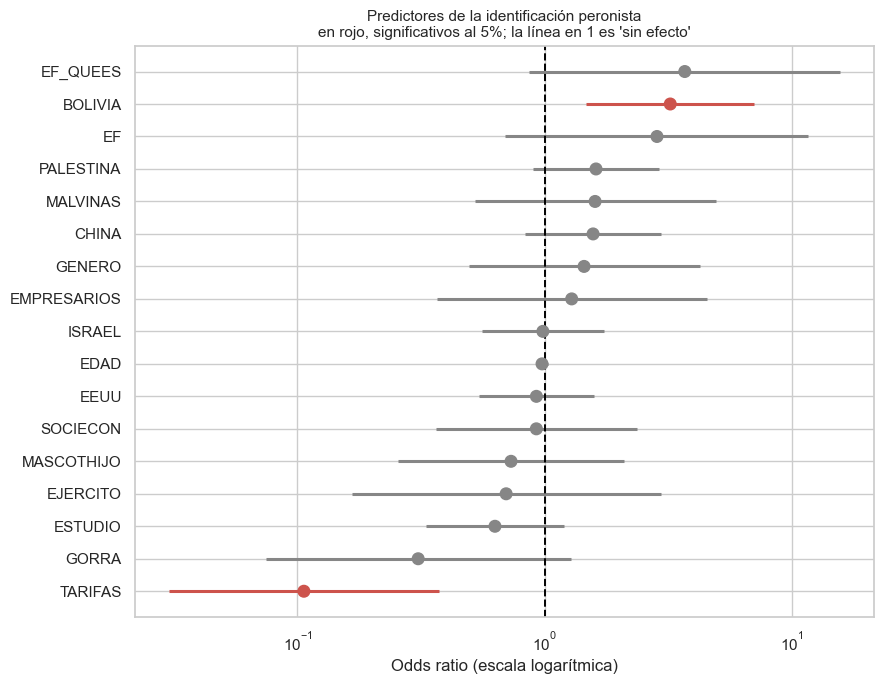

In [33]:
# Gráfico de bosque: odds ratios con sus intervalos
o = odds.sort_values("odds_ratio")
fig, ax = plt.subplots(figsize=(9, 7))

significativo = o["p_valor"] < 0.05
colores = np.where(significativo, PALETA[2], PALETA[3])
pos = np.arange(len(o))

ax.hlines(pos, o["IC_95_inf"], o["IC_95_sup"], color=colores, lw=2.2)
ax.scatter(o["odds_ratio"], pos, color=colores, s=70, zorder=3)
ax.axvline(1, color="black", ls="--", lw=1.4)
ax.set_yticks(pos); ax.set_yticklabels(o.index)
ax.set_xscale("log")
ax.set_xlabel("Odds ratio (escala logarítmica)")
ax.set_title("Predictores de la identificación peronista\n"
             "en rojo, significativos al 5%; la línea en 1 es 'sin efecto'", fontsize=11)
plt.tight_layout()
plt.show()

Dos predictores alcanzan significancia al 5%, y los dos tienen lectura sustantiva directa:

**`TARIFAS`** — *"Está bien que aumenten los servicios y el transporte. Pagábamos muy
poco."* Su *odds ratio* es **0.11**: estar de acuerdo con esa frase multiplica por 0.11 los
odds de identificarse como peronista, o equivalentemente los **divide por nueve**. Es el
predictor más fuerte del modelo, y el intervalo de confianza $[0.03,\ 0.37]$ está
cómodamente por debajo de 1.

**`BOLIVIA`** — la valoración de Bolivia en la escala de $-2$ a $+2$. *Odds ratio* de
**3.22**: cada punto de mejora en la valoración **triplica** los odds de ser peronista. El
intervalo $[1.47,\ 7.04]$ tampoco incluye 1.

El resto no alcanza significancia, lo cual con $n = 132$ y 17 predictores es esperable:
`EF_QUEES` y `GORRA` apuntan en direcciones plausibles pero sus intervalos cruzan el 1.

Sobre el ajuste global: el pseudo-$R^2$ de McFadden es 0.376 y el test de razón de
verosimilitud rechaza el modelo nulo con holgura. El modelo tiene contenido.

> **Por qué esto reemplaza al "test de Wald" hecho a mano.** Una tentación frecuente es
> aproximar la significancia dividiendo cada coeficiente por el desvío de los coeficientes
> **entre clases** y elevando al cuadrado. Eso no es un test de Wald: el estadístico de Wald
> usa el error estándar del coeficiente, que sale de la matriz de información del modelo, no
> la dispersión de coeficientes distintos entre sí. Un p-valor construido con la fórmula
> $1 - e^{-w}$ tampoco corresponde a ninguna distribución de referencia. `statsmodels` ya
> devuelve el estadístico y el p-valor correctos: no hay que reimplementarlos.

### El efecto marginal, que es lo que se puede comunicar

Un *odds ratio* de 3.22 es difícil de comunicar a alguien que no trabaja con odds. Lo
interpretable es el **efecto marginal promedio**: cuántos puntos de probabilidad cambia el
resultado, en promedio, ante un cambio unitario en la variable.

In [34]:
marginales = logit_sm.get_margeff(at="overall", method="dydx")
resumen_marg = pd.DataFrame({
    "efecto_marginal_pp": marginales.margeff * 100,
    "p_valor": marginales.pvalues,
}, index=[c for c in X_sm.columns if c != "const"]).sort_values(
    "efecto_marginal_pp", key=abs, ascending=False)
print("Cambio en la probabilidad de ser peronista, en puntos porcentuales:\n")
resumen_marg.round(2).head(8)

Cambio en la probabilidad de ser peronista, en puntos porcentuales:



,efecto_marginal_pp,p_valor
TARIFAS,-31.20,0.00
EF_QUEES,18.15,0.07
GORRA,-16.40,0.09
BOLIVIA,16.26,0.00
EF,14.54,0.13
PALESTINA,6.64,0.10
MALVINAS,6.52,0.41
ESTUDIO,-6.45,0.15


Ahora sí se puede decir en una oración: **estar de acuerdo con el aumento de tarifas reduce
en 31 puntos porcentuales la probabilidad de identificarse como peronista**, y cada punto de
mejor valoración de Bolivia la aumenta en 16.

Notar que el orden de los efectos marginales no es el mismo que el de los *odds ratios*.
`EF_QUEES` y `GORRA` tienen efectos marginales grandes (+18 y −16 puntos) con p-valores de
0.07 y 0.09: quedan al borde de la significancia. Con 132 casos, "no significativo" quiere
decir "esta muestra no alcanza para distinguirlo de cero", no "no hay efecto".

## Un predictor que casi es la respuesta

La encuesta incluye `MILEI`: el nivel de satisfacción con el gobierno de Milei, en una escala
de 0 a 4. La dejamos deliberadamente afuera del modelo. Veamos qué pasa si la agregamos.

In [35]:
X_con_milei = datos[NUMERICAS + ["MILEI"] + CATEGORICAS]

pre_milei = ColumnTransformer([
    ("num", Pipeline([("imputar", SimpleImputer(strategy="median")),
                      ("escalar", StandardScaler())]), NUMERICAS + ["MILEI"]),
    ("cat", Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),
                      ("dummies", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                                min_frequency=6,
                                                sparse_output=False))]), CATEGORICAS),
])
pipe_milei = Pipeline([("pre", pre_milei),
                       ("clf", LogisticRegression(C=0.2081, l1_ratio=0.5, solver="saga",
                                                  max_iter=20000, random_state=SEED))])

comp_milei = pd.DataFrame([
    evaluar(armar_logit(C=0.2081, l1_ratio=0.5), X, y3, "3 clases · sin MILEI"),
    evaluar(pipe_milei, X_con_milei, y3, "3 clases · con MILEI"),
])
comp_milei.round(3)

,modelo,exactitud,exac_sd,f1_macro,f1_sd,exac_balanceada
0,3 clases · sin MILEI,0.712,0.065,0.473,0.062,0.500
1,3 clases · con MILEI,0.743,0.061,0.546,0.089,0.557


In [36]:
print("Satisfacción con el gobierno por bloque ideológico (0 = nada, 4 = mucho):")
print(datos.assign(bloque=y3).groupby("bloque")["MILEI"].agg(["mean", "std", "count"]).round(2))
print()
print(pd.crosstab(y3, datos["MILEI"], normalize="index").round(2) * 100)

Satisfacción con el gobierno por bloque ideológico (0 = nada, 4 = mucho):
                       mean   std  count
bloque                                  
Derecha/Liberal        2.88  0.86     17
Peronismo/Izquierda    0.22  0.57     79
Sin adscripción clara  1.75  1.11     36

MILEI                     0     1     2     3     4
ETIQUETA                                           
Derecha/Liberal         0.0   6.0  24.0  47.0  24.0
Peronismo/Izquierda    85.0  10.0   4.0   1.0   0.0
Sin adscripción clara  17.0  19.0  42.0  17.0   6.0


Agregar `MILEI` mejora la exactitud unos 3 puntos. Poco, y por una razón interesante: la
variable es **casi la respuesta con otro nombre**. La tabla muestra que el bloque
peronismo/izquierda promedia 0.4 en satisfacción con el gobierno y el bloque derecha/liberal
promedia 2.8. Preguntar por la satisfacción con el gobierno de Milei es, en este contexto,
otra manera de preguntar la identificación política.

No es *leakage* en sentido estricto —es una variable legítimamente medida, disponible en el
momento de predecir— pero sí es **circular** para la pregunta de investigación. Si lo que
queremos saber es qué actitudes sobre temas concretos estructuran la identificación
política, incluir "¿le gusta el gobierno actual?" no responde eso: lo esquiva.

La decisión de excluirla es sustantiva, no técnica. Y merece quedar escrita, porque un lector
que compare este modelo con otro que la incluya va a ver una diferencia de performance que
no es una diferencia de calidad.

## Cierre aplicado: a quién le habla una campaña

Un modelo de clasificación política no sirve para poner etiquetas a la gente. Sirve para
**ordenar decisiones bajo restricción de recursos**.

El problema concreto: una campaña tiene presupuesto para contactar al 30% de un padrón y
quiere maximizar el contacto con votantes de su espacio. ¿Cómo elige a quién llamar?

Sin modelo, la respuesta es al azar: contactando al 30% se alcanza al 30% de los votantes
propios. Con modelo, se ordena por probabilidad predicha y se contacta desde arriba.

Todas las probabilidades de esta sección son **fuera de muestra** —`cross_val_predict`, o
sea que la predicción de cada caso viene de un modelo que no lo vio—, porque calcularlas
sobre los mismos datos que ajustaron el modelo daría una ganancia ficticia.

In [37]:
modelo_final = armar_logit(C=0.2081, l1_ratio=0.5)

# probabilidades honestas: cada caso predicho por un modelo que no lo vio
proba_fm = cross_val_predict(modelo_final, X, y2, cv=CV_PRED,
                             method="predict_proba", n_jobs=-1)

clases = np.unique(y2)
idx_peronista = list(clases).index("Peronista")

ranking = pd.DataFrame({
    "prob_peronista": proba_fm[:, idx_peronista],
    "es_peronista": (y2 == "Peronista").astype(int).values,
    "etiqueta_real": y.values,
}).sort_values("prob_peronista", ascending=False).reset_index(drop=True)

print(f"casos: {len(ranking)}   peronistas reales: {ranking['es_peronista'].sum()}")
ranking.head(8).round(3)

casos: 132   peronistas reales: 60


,prob_peronista,es_peronista,etiqueta_real
0,0.941,1,Peronista
1,0.939,1,Peronista
2,0.938,1,Peronista
3,0.929,0,De izquierda
4,0.923,1,Peronista
5,0.921,0,De izquierda
6,0.918,1,Peronista
7,0.913,1,Peronista


C:\Users\mmill\anaconda3\envs\PYR\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


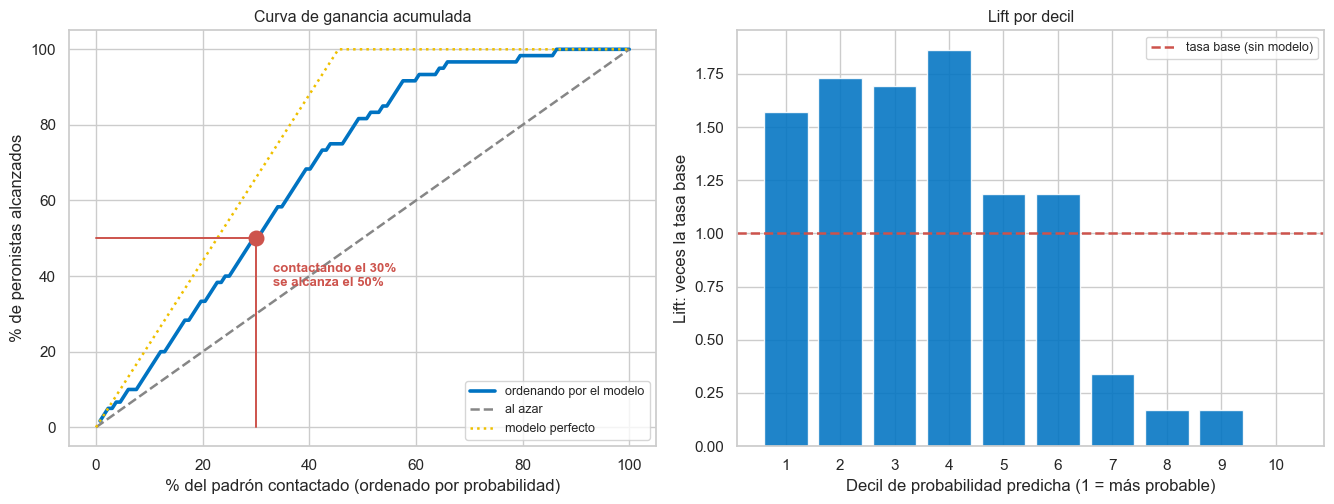

In [38]:
# Curva de ganancia acumulada
ranking["captura_acum"] = ranking["es_peronista"].cumsum() / ranking["es_peronista"].sum()
ranking["fraccion_contactada"] = (np.arange(len(ranking)) + 1) / len(ranking)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

ax = axes[0]
ax.plot(ranking["fraccion_contactada"] * 100, ranking["captura_acum"] * 100,
        lw=2.6, color=PALETA[0], label="ordenando por el modelo")
ax.plot([0, 100], [0, 100], ls="--", color=PALETA[3], lw=1.8, label="al azar")
tasa = ranking["es_peronista"].mean()
ax.plot([0, tasa * 100, 100], [0, 100, 100], ls=":", color=PALETA[1], lw=1.8,
        label="modelo perfecto")
for f in [30]:
    i = int(f / 100 * len(ranking)) - 1
    captura = ranking["captura_acum"].iloc[i] * 100
    ax.plot([f, f], [0, captura], color=PALETA[2], lw=1.4, ls="-")
    ax.plot([0, f], [captura, captura], color=PALETA[2], lw=1.4, ls="-")
    ax.scatter([f], [captura], s=110, color=PALETA[2], zorder=5)
    ax.annotate(f"contactando el {f}%\nse alcanza el {captura:.0f}%",
                (f, captura), xytext=(12, -34), textcoords="offset points",
                fontsize=9.5, color=PALETA[2], fontweight="bold")
ax.set_xlabel("% del padrón contactado (ordenado por probabilidad)")
ax.set_ylabel("% de peronistas alcanzados")
ax.set_title("Curva de ganancia acumulada", fontsize=11.5)
ax.legend(fontsize=9, loc="lower right")

ax = axes[1]
deciles = np.array_split(ranking, 10)
lift = [d["es_peronista"].mean() / tasa for d in deciles]
ax.bar(range(1, 11), lift, color=PALETA[0], alpha=0.88)
ax.axhline(1, color=PALETA[2], ls="--", lw=1.8, label="tasa base (sin modelo)")
ax.set_xticks(range(1, 11))
ax.set_xlabel("Decil de probabilidad predicha (1 = más probable)")
ax.set_ylabel("Lift: veces la tasa base")
ax.set_title("Lift por decil", fontsize=11.5)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [39]:
print("Ganancia por tramo del padrón:\n")
for f in [0.1, 0.2, 0.3, 0.4, 0.5]:
    i = int(f * len(ranking)) - 1
    captura = ranking["captura_acum"].iloc[i]
    print(f"  contactar el {f*100:3.0f}%  ->  se alcanza el {captura*100:5.1f}% "
          f"de los peronistas   (lift = {captura/f:.2f}×)")

Ganancia por tramo del padrón:

  contactar el  10%  ->  se alcanza el  15.0% de los peronistas   (lift = 1.50×)
  contactar el  20%  ->  se alcanza el  33.3% de los peronistas   (lift = 1.67×)
  contactar el  30%  ->  se alcanza el  50.0% de los peronistas   (lift = 1.67×)
  contactar el  40%  ->  se alcanza el  68.3% de los peronistas   (lift = 1.71×)
  contactar el  50%  ->  se alcanza el  81.7% de los peronistas   (lift = 1.63×)


Con el 30% del padrón se alcanza **exactamente la mitad** de los votantes del espacio: un
**lift de 1.67**, o sea dos tercios más de eficiencia que llamar al azar. Ese número es el
producto concreto del modelo, y es lo que permite decidir si vale la pena construirlo: para
alcanzar a la mitad del electorado propio, una campaña sin modelo tendría que contactar al
50% del padrón y con modelo le alcanza el 30%. Sobre un presupuesto de contacto, eso es un
ahorro del 40%.

El lift se mantiene entre 1.5 y 1.7 en todos los tramos, sin un decil que concentre casi
todos los casos positivos. Eso es coherente con un modelo que discrimina de forma moderada y
consistente, y no con uno que identifica un núcleo pequeño con certeza.

### El segmento persuadible

El ranking sirve para otra cosa además de priorizar: **identificar a los indecisos**.

Los casos con probabilidad cercana a 0.5 no son los que el modelo clasifica mal — son los
que están genuinamente en el límite: tienen posiciones mezcladas, algunas típicas del
espacio y otras no. En términos de campaña, es el segmento donde el mensaje puede mover algo,
porque los de probabilidad 0.95 ya están convencidos y los de 0.05 son inalcanzables.

In [40]:
ranking_completo = pd.DataFrame({
    "prob_peronista": proba_fm[:, idx_peronista],
    "etiqueta_real": y.values,
}, index=datos.index)

def segmento(p):
    if p >= 0.65:
        return "Núcleo propio"
    if p <= 0.35:
        return "Fuera de alcance"
    return "Persuadible"

ranking_completo["segmento"] = ranking_completo["prob_peronista"].apply(segmento)
perfil = ranking_completo.groupby("segmento").agg(
    casos=("prob_peronista", "size"),
    prob_media=("prob_peronista", "mean"),
    pct_peronistas_reales=("etiqueta_real", lambda s: (s == "Peronista").mean() * 100),
).round(2).loc[["Núcleo propio", "Persuadible", "Fuera de alcance"]]
perfil

,casos,prob_media,pct_peronistas_reales
segmento,,,
Núcleo propio,40,0.81,75.00
Persuadible,39,0.51,64.10
Fuera de alcance,53,0.18,9.43


In [41]:
# Qué distingue al segmento persuadible
comparables = ["TARIFAS", "BOLIVIA", "GORRA", "EMPRESARIOS", "PALESTINA", "EEUU",
               "MALVINAS", "EDAD", "ESTUDIO"]
tabla_perfil = (datos.assign(segmento=ranking_completo["segmento"])
                .groupby("segmento")[comparables].mean()
                .loc[["Núcleo propio", "Persuadible", "Fuera de alcance"]].round(2))
tabla_perfil

,TARIFAS,BOLIVIA,GORRA,EMPRESARIOS,PALESTINA,EEUU,MALVINAS,EDAD,ESTUDIO
segmento,,,,,,,,,
Núcleo propio,0.05,1.48,0.38,0.45,0.80,-1.15,0.52,29.22,2.62
Persuadible,0.10,0.77,0.21,0.41,0.05,-0.71,0.44,29.26,2.38
Fuera de alcance,0.75,-0.06,0.11,0.25,-0.19,-0.04,0.58,30.87,2.44


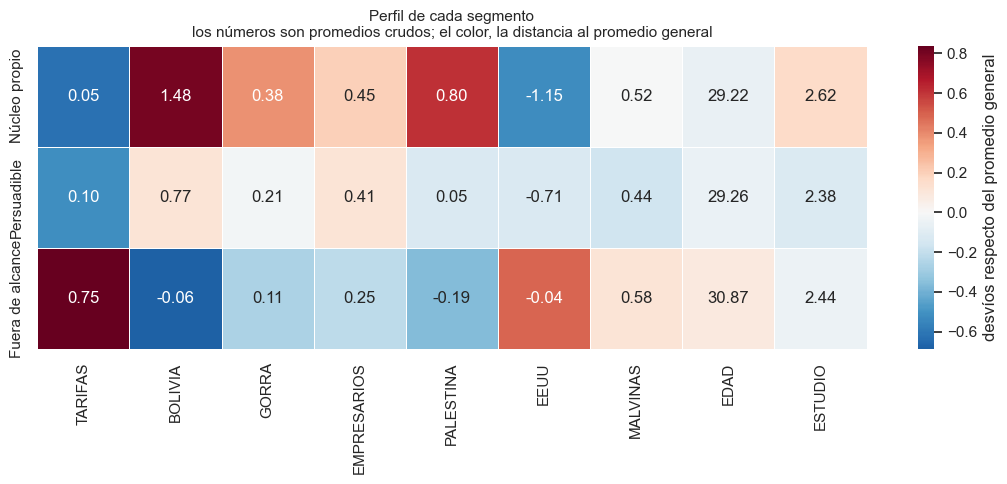

In [42]:
fig, ax = plt.subplots(figsize=(11, 5))
z = ((tabla_perfil - datos[comparables].mean()) / datos[comparables].std())
sns.heatmap(z, annot=tabla_perfil.values, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.6, cbar_kws={"label": "desvíos respecto del promedio general"}, ax=ax)
ax.set_title("Perfil de cada segmento\n"
             "los números son promedios crudos; el color, la distancia al promedio general",
             fontsize=11)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

El segmento persuadible —26 casos, un 20% de la muestra— tiene casi exactamente la mitad de
peronistas reales, lo que confirma que el modelo no está fallando ahí sino describiendo una
zona realmente ambigua. Su perfil se ubica **entre** los otros dos en casi todas las
variables, con una excepción interesante: en la valoración de Bolivia y en `TARIFAS` está
más cerca del núcleo propio que del segmento inalcanzable.

Eso es accionable: sugiere que a este grupo le habla mejor un mensaje sobre tarifas y
servicios públicos que uno sobre política internacional.

### Perfiles construidos a mano

La otra forma de usar el modelo: darle un caso hipotético y leer su probabilidad. Es lo que
permite testear un perfil antes de salir a buscarlo.

In [43]:
modelo_ajustado = armar_logit(C=0.2081, l1_ratio=0.5).fit(X, y2)

base = X.median(numeric_only=True).to_dict()
for c in CATEGORICAS:
    base[c] = datos[c].mode()[0]

perfiles = {
    "Joven crítico del ajuste": {**base, "EDAD": 26, "TARIFAS": 0, "GORRA": 1,
                                 "EMPRESARIOS": 1, "BOLIVIA": 2, "PALESTINA": 2,
                                 "EEUU": -2, "ESTUDIO": 3, "NOTICIAS": "C5N"},
    "Profesional pro-mercado": {**base, "EDAD": 45, "TARIFAS": 1, "GORRA": 0,
                                "EMPRESARIOS": 0, "BOLIVIA": -1, "PALESTINA": -1,
                                "EEUU": 2, "ESTUDIO": 4, "NOTICIAS": "TN"},
    "Desinteresado de la política": {**base, "EDAD": 33, "TARIFAS": 1, "GORRA": 0,
                                     "EMPRESARIOS": 1, "BOLIVIA": 0, "PALESTINA": 0,
                                     "EEUU": 0, "ESTUDIO": 2,
                                     "NOTICIAS": "Prefiero no ver nada"},
}

filas_perfil = pd.DataFrame([perfiles[k] for k in perfiles], index=list(perfiles))[X.columns]
probas = modelo_ajustado.predict_proba(filas_perfil)[:, idx_peronista]

resultado = pd.DataFrame({
    "prob. de ser peronista": probas.round(3),
    "segmento": [segmento(p) for p in probas],
}, index=list(perfiles))
resultado

,prob. de ser peronista,segmento
Joven crítico del ajuste,0.851,Núcleo propio
Profesional pro-mercado,0.085,Fuera de alcance
Desinteresado de la política,0.151,Fuera de alcance


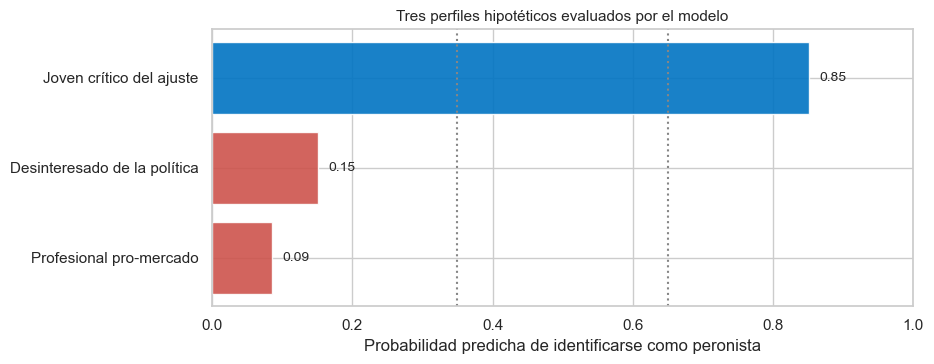

In [44]:
fig, ax = plt.subplots(figsize=(9.5, 3.8))
orden = resultado.sort_values("prob. de ser peronista")
colores = [PALETA[2] if p < 0.35 else PALETA[1] if p < 0.65 else PALETA[0]
           for p in orden["prob. de ser peronista"]]
ax.barh(orden.index, orden["prob. de ser peronista"], color=colores, alpha=0.9)
ax.axvline(0.35, color=PALETA[3], ls=":", lw=1.5)
ax.axvline(0.65, color=PALETA[3], ls=":", lw=1.5)
for i, (nombre, fila) in enumerate(orden.iterrows()):
    ax.text(fila["prob. de ser peronista"] + 0.015, i,
            f"{fila['prob. de ser peronista']:.2f}", va="center", fontsize=10)
ax.set_xlim(0, 1)
ax.set_xlabel("Probabilidad predicha de identificarse como peronista")
ax.set_title("Tres perfiles hipotéticos evaluados por el modelo", fontsize=11)
plt.tight_layout()
plt.show()

### El producto

Lo que este notebook entrega no es un número de exactitud, son tres cosas usables:

1. **Un ranking de contactabilidad**: con el 30% del padrón se alcanza el 50% de los
   votantes del espacio, contra el 30% que daría el azar. Eso convierte un presupuesto de
   campaña en una lista priorizada.
2. **Un segmento persuadible identificado y perfilado**: 26 casos con posiciones mezcladas,
   más cercanos al espacio propio en tarifas y política regional que en el resto de los
   temas. Eso convierte el modelo en una decisión de mensaje.
3. **Dos hallazgos sustantivos con intervalo de confianza**: la posición sobre tarifas divide
   por nueve los odds de identificación peronista, y la valoración de Bolivia los triplica.
   Eso es lo que puede entrar en un informe.

Y una limitación que hay que escribir junto a los tres puntos: la muestra tiene 132 casos y
no es probabilística, así que estos resultados describen a **quienes respondieron este
formulario** y no a la población argentina. La metodología es transferible; los números, no.

## Síntesis

1. La logística modela el **logaritmo de los odds** como función lineal de los predictores.
   Sus coeficientes exponenciados son *odds ratios*, multiplicativos sobre los odds y no
   sobre las probabilidades. Su frontera de decisión es un hiperplano, y esa es su
   limitación.

2. **La depuración es parte del método.** Descartamos dos etiquetas inválidas y tres
   variables rotas por errores del cuestionario, y **conservamos** el caso de 78 años:
   atípico no es inválido, y el criterio para descartar es saber por qué el dato está mal.

3. **Los faltantes estructurales no se imputan.** `DESIGUALDAD`/`NO_PIENSAN` son ramas
   complementarias de una bifurcación, y los nulos de `GRUPO`/`PROLE` son exactamente
   quienes no trabajan. Imputar la moda ahí inventa respuestas y destruye información; la
   solución es codificar la estructura como una categoría más.

4. **Hay que buscar separación perfecta y varianza casi nula antes de estimar.** `UP` tiene
   un 2.3% de minoría y ninguna persona que se oponga es peronista: el estimador de máxima
   verosimilitud no existe y el software devuelve un *odds ratio* de $10^{15}$ sin avisar.

5. Con 7 clases y 132 casos el modelo mejora el $F_1$ macro de 0.089 a **0.236**, pero su
   ganancia en exactitud (+4 puntos) es **menor que el desvío entre pliegues**: en exactitud
   empata con el baseline. Tres clases tienen entre 7 y 10 casos y en cada pliegue de
   validación aparecen una o dos veces.

6. **Agrupar clases cambia la pregunta, no mejora el modelo.** La división
   peronismo/no peronismo llega a **0.791** de exactitud contra 0.545 de baseline, con una
   ganancia de más de tres desvíos, y eso sugiere que el eje que estas variables capturan es
   ese y no una escala de siete posiciones.

7. Para **inferencia** hay que salir de scikit-learn: los coeficientes penalizados están
   sesgados por diseño y no traen errores estándar. `statsmodels` da odds ratios con
   intervalos, y `get_margeff` los traduce a puntos porcentuales, que es lo comunicable.

8. El cierre no es una métrica: es un **ranking priorizado con lift de 1.67×** y un segmento
   persuadible de 26 casos identificado y perfilado.

## Lo que sigue

En `9.3` cambiamos la familia de modelos: en lugar de una frontera lineal, particiones del
espacio. Ahí el desarrollo va sobre 7.233 mesas de la elección porteña de 2025, porque con esa
cantidad de casos los gráficos de diagnóstico se leen y los métodos tienen lugar para mostrarse.

Y `9.3b` vuelve a esta misma encuesta con los mismos métodos, para ver si un árbol, un Random
Forest y XGBoost le ganan a este logit. La respuesta, con 132 casos, es parte de la lección.